<a href="https://colab.research.google.com/github/vinitdarji16/MLS-Exercise/blob/main/MLS_exercises_vehicle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import zipfile
import os

dataset_path = "/content/drive/MyDrive/dataset for MLS"

for file in [
    "train.zip",
    "validation.zip",
    "test.zip",
    "test-fog.zip",
    "test-night.zip",
    "test-town-01.zip"
]:
    zip_path = os.path.join(dataset_path, file)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
!ls /content/dataset

test  test-fog	test-night  test-town-01  train  validation


In [5]:
import torch

print("GPU Available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

GPU Available: True
GPU: Tesla T4


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from PIL import Image
import os

In [7]:
train_labels = pd.read_csv("/content/dataset/train/labels.csv")
val_labels = pd.read_csv("/content/dataset/validation/labels.csv")
test_labels = pd.read_csv("/content/dataset/test/labels.csv")

print("Training images:", len(train_labels))
print("Validation images:", len(val_labels))
print("Test images:", len(test_labels))

Training images: 7200
Validation images: 3600
Test images: 3600


In [8]:
print(train_labels.head())
print("\nColumns:")
print(train_labels.columns)

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  

Columns:
Index(['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle',
       'px_traffic_light', 'px_pedestrian', 'px_vehicle'],
      dtype='object')


In [9]:
labels = ["has_traffic_light", "has_pedestrian", "has_vehicle"]

for label in labels:
    print(f"\n{label}")
    print(train_labels[label].value_counts())


has_traffic_light
has_traffic_light
True     5276
False    1924
Name: count, dtype: int64

has_pedestrian
has_pedestrian
False    5482
True     1718
Name: count, dtype: int64

has_vehicle
has_vehicle
True     5458
False    1742
Name: count, dtype: int64


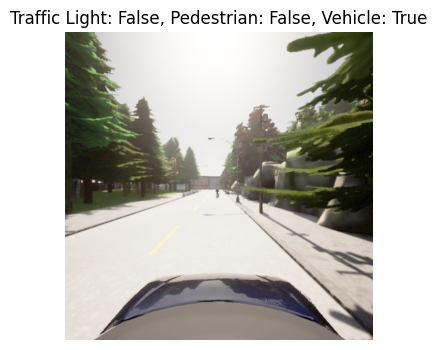

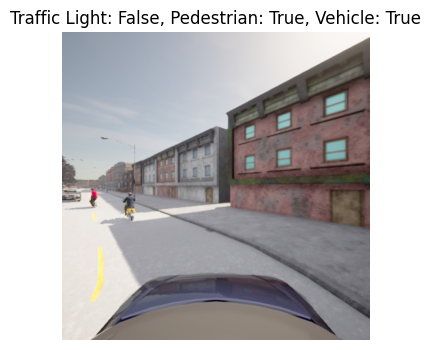

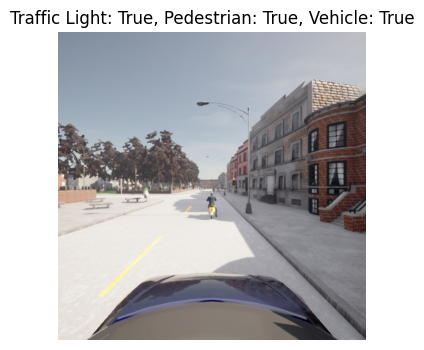

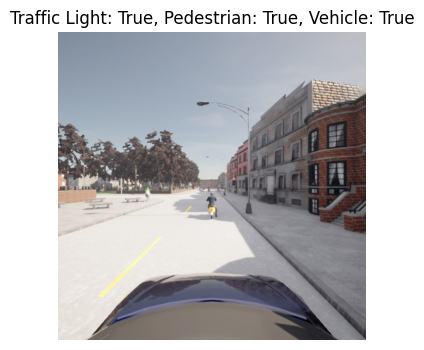

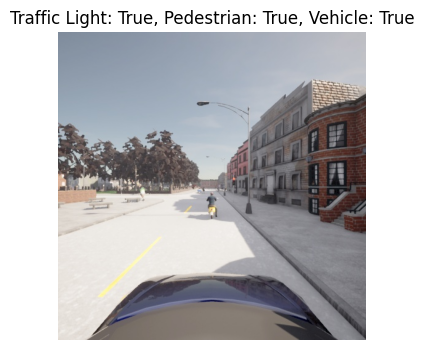

In [10]:
import matplotlib.pyplot as plt
from PIL import Image
import os

image_folder = "/content/dataset/train/rgb-front"

for i in range(5):

    frame = train_labels.iloc[i]["frame"]

    image_name = f"{frame:06d}.jpg"
    image_path = os.path.join(image_folder, image_name)

    img = Image.open(image_path)

    plt.figure(figsize=(6,4))
    plt.imshow(img)

    plt.title(
        f"Traffic Light: {train_labels.iloc[i]['has_traffic_light']}, "
        f"Pedestrian: {train_labels.iloc[i]['has_pedestrian']}, "
        f"Vehicle: {train_labels.iloc[i]['has_vehicle']}"
    )

    plt.axis("off")
    plt.show()

In [11]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully!")

Transforms created successfully!


In [12]:
class CarlaDataset(Dataset):
    def __init__(self, image_folder, labels_df, target_column, transform=None):
        self.image_folder = image_folder
        self.labels_df = labels_df
        self.target_column = target_column
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        frame = self.labels_df.iloc[idx]["frame"]

        image_name = f"{frame:06d}.jpg"
        image_path = os.path.join(self.image_folder, image_name)

        image = Image.open(image_path).convert("RGB")

        label = int(self.labels_df.iloc[idx][self.target_column])

        if self.transform:
            image = self.transform(image)

        return image, label

print("Dataset class created successfully!")

Dataset class created successfully!


In [13]:
train_image_folder = "/content/dataset/train/rgb-front"
val_image_folder = "/content/dataset/validation/rgb-front"

vehicle_train_dataset = CarlaDataset(
    train_image_folder,
    train_labels,
    "has_vehicle",
    transform
)

vehicle_val_dataset = CarlaDataset(
    val_image_folder,
    val_labels,
    "has_vehicle",
    transform
)

print("vehicle datasets created!")
print("Training samples:", len(vehicle_train_dataset))
print("Validation samples:", len(vehicle_val_dataset))

vehicle datasets created!
Training samples: 7200
Validation samples: 3600


In [14]:
train_loader = DataLoader(
    vehicle_train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    vehicle_val_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [15]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


In [16]:
from torchvision import models
import torch.nn as nn

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

model = model.to("cuda")

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and optimizer created successfully!")

Loss and optimizer created successfully!


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [19]:
num_epochs = 10

model = model.to(device)

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_train_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # VALIDATION
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

print("Training completed!")

Epoch [1/10] | Train Loss: 0.3529 | Val Loss: 0.3279
Epoch [2/10] | Train Loss: 0.2360 | Val Loss: 0.3558
Epoch [3/10] | Train Loss: 0.2042 | Val Loss: 0.3179
Epoch [4/10] | Train Loss: 0.1691 | Val Loss: 0.2662
Epoch [5/10] | Train Loss: 0.1593 | Val Loss: 0.3028
Epoch [6/10] | Train Loss: 0.1494 | Val Loss: 0.2810
Epoch [7/10] | Train Loss: 0.1317 | Val Loss: 0.3161
Epoch [8/10] | Train Loss: 0.1104 | Val Loss: 0.3123
Epoch [9/10] | Train Loss: 0.1115 | Val Loss: 0.3138
Epoch [10/10] | Train Loss: 0.0936 | Val Loss: 0.3587
Training completed!


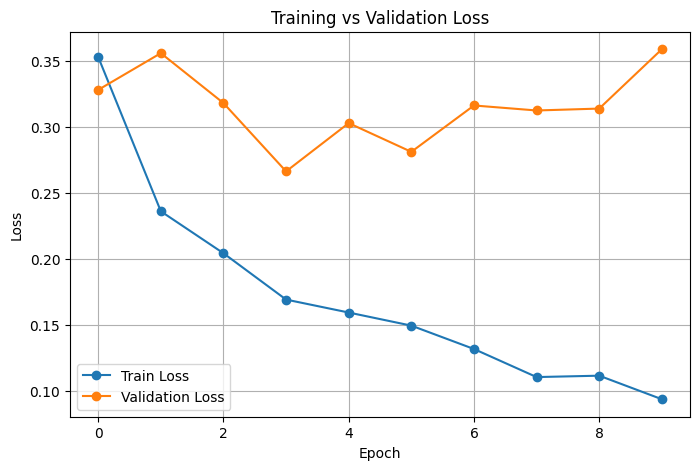

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o', label='Train Loss')
plt.plot(val_losses, marker='o', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.grid(True)
plt.show()

In [21]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).squeeze().long()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 89.42%


In [22]:
test_image_folder = "/content/dataset/test/rgb-front"

vehicle_test_dataset = CarlaDataset(
    test_image_folder,
    test_labels,
    "has_vehicle",
    transform
)

test_loader = DataLoader(
    vehicle_test_dataset,
    batch_size=32,
    shuffle=False
)

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = (torch.sigmoid(outputs) > 0.5).squeeze().cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print("Accuracy :", accuracy_score(all_labels, all_preds))
print("Precision:", precision_score(all_labels, all_preds))
print("Recall   :", recall_score(all_labels, all_preds))
print("F1 Score :", f1_score(all_labels, all_preds))

Accuracy : 0.8869444444444444
Precision: 0.9537000395726157
Recall   : 0.8925925925925926
F1 Score : 0.922135067916587


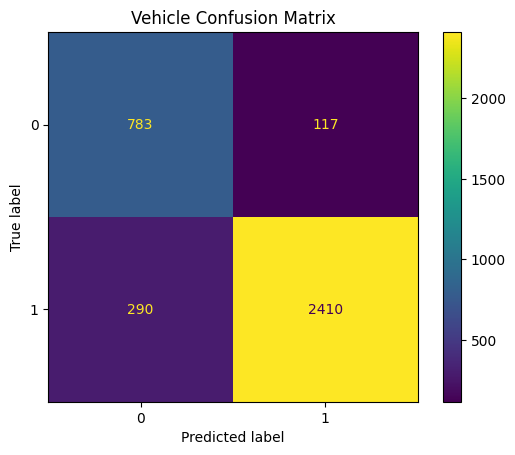

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Vehicle Confusion Matrix")
plt.show()

In [25]:
import torch
from sklearn.metrics import accuracy_score

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            scaled_outputs = outputs / T

            probs = torch.sigmoid(scaled_outputs)

            preds = (probs > 0.5).squeeze().cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"Temperature = {T}")
    print(f"Accuracy = {acc:.4f}")
    print("-"*30)

Temperature = 0.5
Accuracy = 0.8869
------------------------------
Temperature = 1.0
Accuracy = 0.8869
------------------------------
Temperature = 2.0
Accuracy = 0.8869
------------------------------


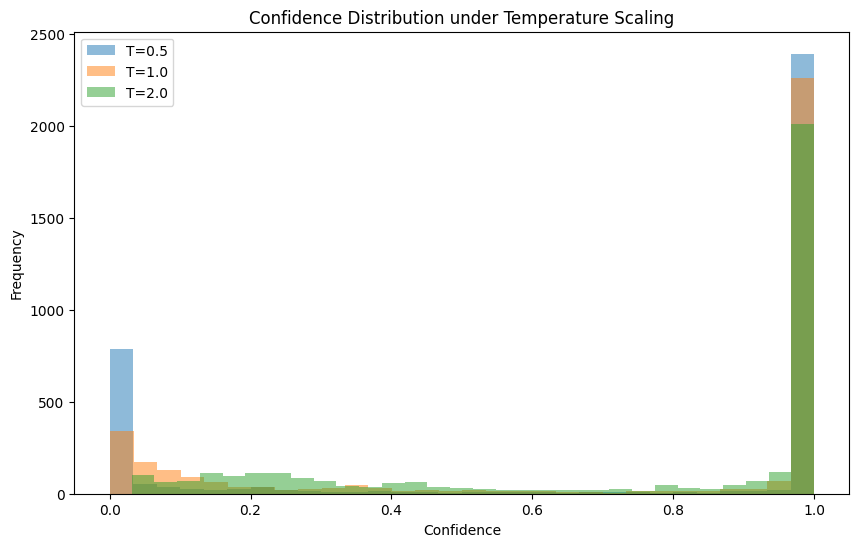

In [26]:
import matplotlib.pyplot as plt

temperatures = [0.5,1.0,2.0]

plt.figure(figsize=(10,6))

for T in temperatures:

    confidences=[]

    model.eval()

    with torch.no_grad():

        for images,labels in test_loader:

            images=images.to(device)

            outputs=model(images)

            scaled_outputs=outputs/T

            probs=torch.sigmoid(scaled_outputs)

            confidences.extend(probs.squeeze().cpu().numpy())

    plt.hist(confidences,bins=30,alpha=0.5,label=f"T={T}")

plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.title("Confidence Distribution under Temperature Scaling")
plt.legend()
plt.show()

Exercise 6.5 - Grad-CAM Explainability

In [27]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 64.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=52d63db77b07ac83d67c7608366b54fa7dcff0f81013ce5a7c3418166d21c6eb
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt
import torch

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [29]:
model.eval()

correct_vehicle = []
wrong_predictions = []

with torch.no_grad():

    for batch_idx, (images, labels) in enumerate(test_loader):

        images = images.to(device)

        outputs = model(images)
        preds = (torch.sigmoid(outputs) > 0.5).squeeze().long()

        for i in range(len(labels)):

            true_label = labels[i].item()
            pred_label = preds[i].item()

            sample_id = batch_idx * 32 + i

            if true_label == 1 and pred_label == 1:
                correct_vehicle.append(sample_id)

            if true_label != pred_label:
                wrong_predictions.append(sample_id)

print("Correct vehicle examples:")
print(correct_vehicle[:10])

print("\nWrong predictions:")
print(wrong_predictions[:10])

Correct vehicle examples:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Wrong predictions:
[14, 15, 16, 21, 30, 42, 44, 45, 49, 79]


Grad-CAM for a Correct Vehicle Detection

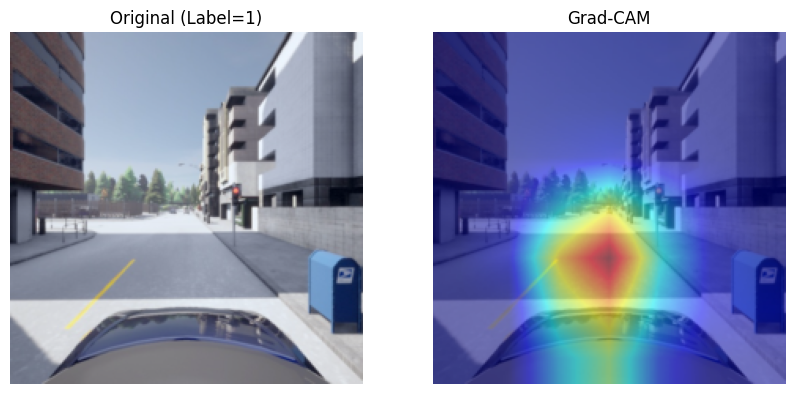

In [30]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

sample_idx = 1      # Correct vehicle example

img, label = vehicle_test_dataset[sample_idx]

input_tensor = img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

img_np = img.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())

visualization = show_cam_on_image(
    img_np.astype(np.float32),
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f"Original (Label={label})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

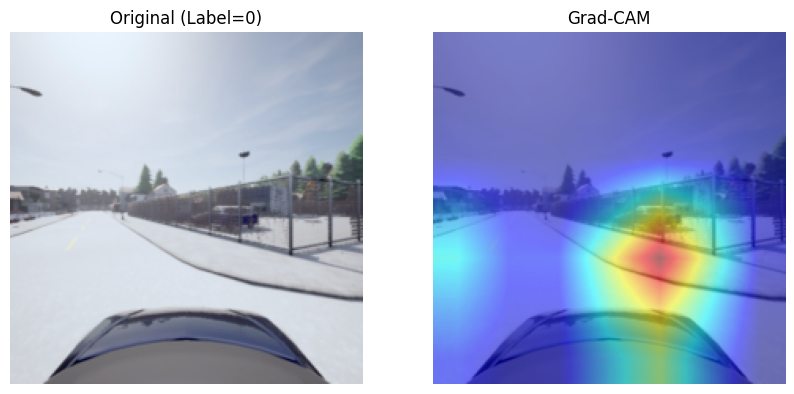

In [31]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

sample_idx = 14      # Wrong prediction

img, label = vehicle_test_dataset[sample_idx]

input_tensor = img.unsqueeze(0).to(device)

grayscale_cam = cam(input_tensor=input_tensor)[0]

img_np = img.permute(1,2,0).cpu().numpy()
img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())

visualization = show_cam_on_image(
    img_np.astype(np.float32),
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title(f"Original (Label={label})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(visualization)
plt.title("Grad-CAM")
plt.axis("off")

plt.show()

Exercise 7


In [32]:
fog_labels = pd.read_csv("/content/dataset/test-fog/labels.csv")
night_labels = pd.read_csv("/content/dataset/test-night/labels.csv")
town_labels = pd.read_csv("/content/dataset/test-town-01/labels.csv")

fog_image_folder = "/content/dataset/test-fog/rgb-front"
night_image_folder = "/content/dataset/test-night/rgb-front"
town_image_folder = "/content/dataset/test-town-01/rgb-front"

fog_dataset = CarlaDataset(
    fog_image_folder,
    fog_labels,
    "has_vehicle",
    transform
)

night_dataset = CarlaDataset(
    night_image_folder,
    night_labels,
    "has_vehicle",
    transform
)

town_dataset = CarlaDataset(
    town_image_folder,
    town_labels,
    "has_vehicle",
    transform
)

fog_loader = DataLoader(fog_dataset, batch_size=32, shuffle=False)
night_loader = DataLoader(night_dataset, batch_size=32, shuffle=False)
town_loader = DataLoader(town_dataset, batch_size=32, shuffle=False)

print("OOD datasets loaded successfully!")

OOD datasets loaded successfully!


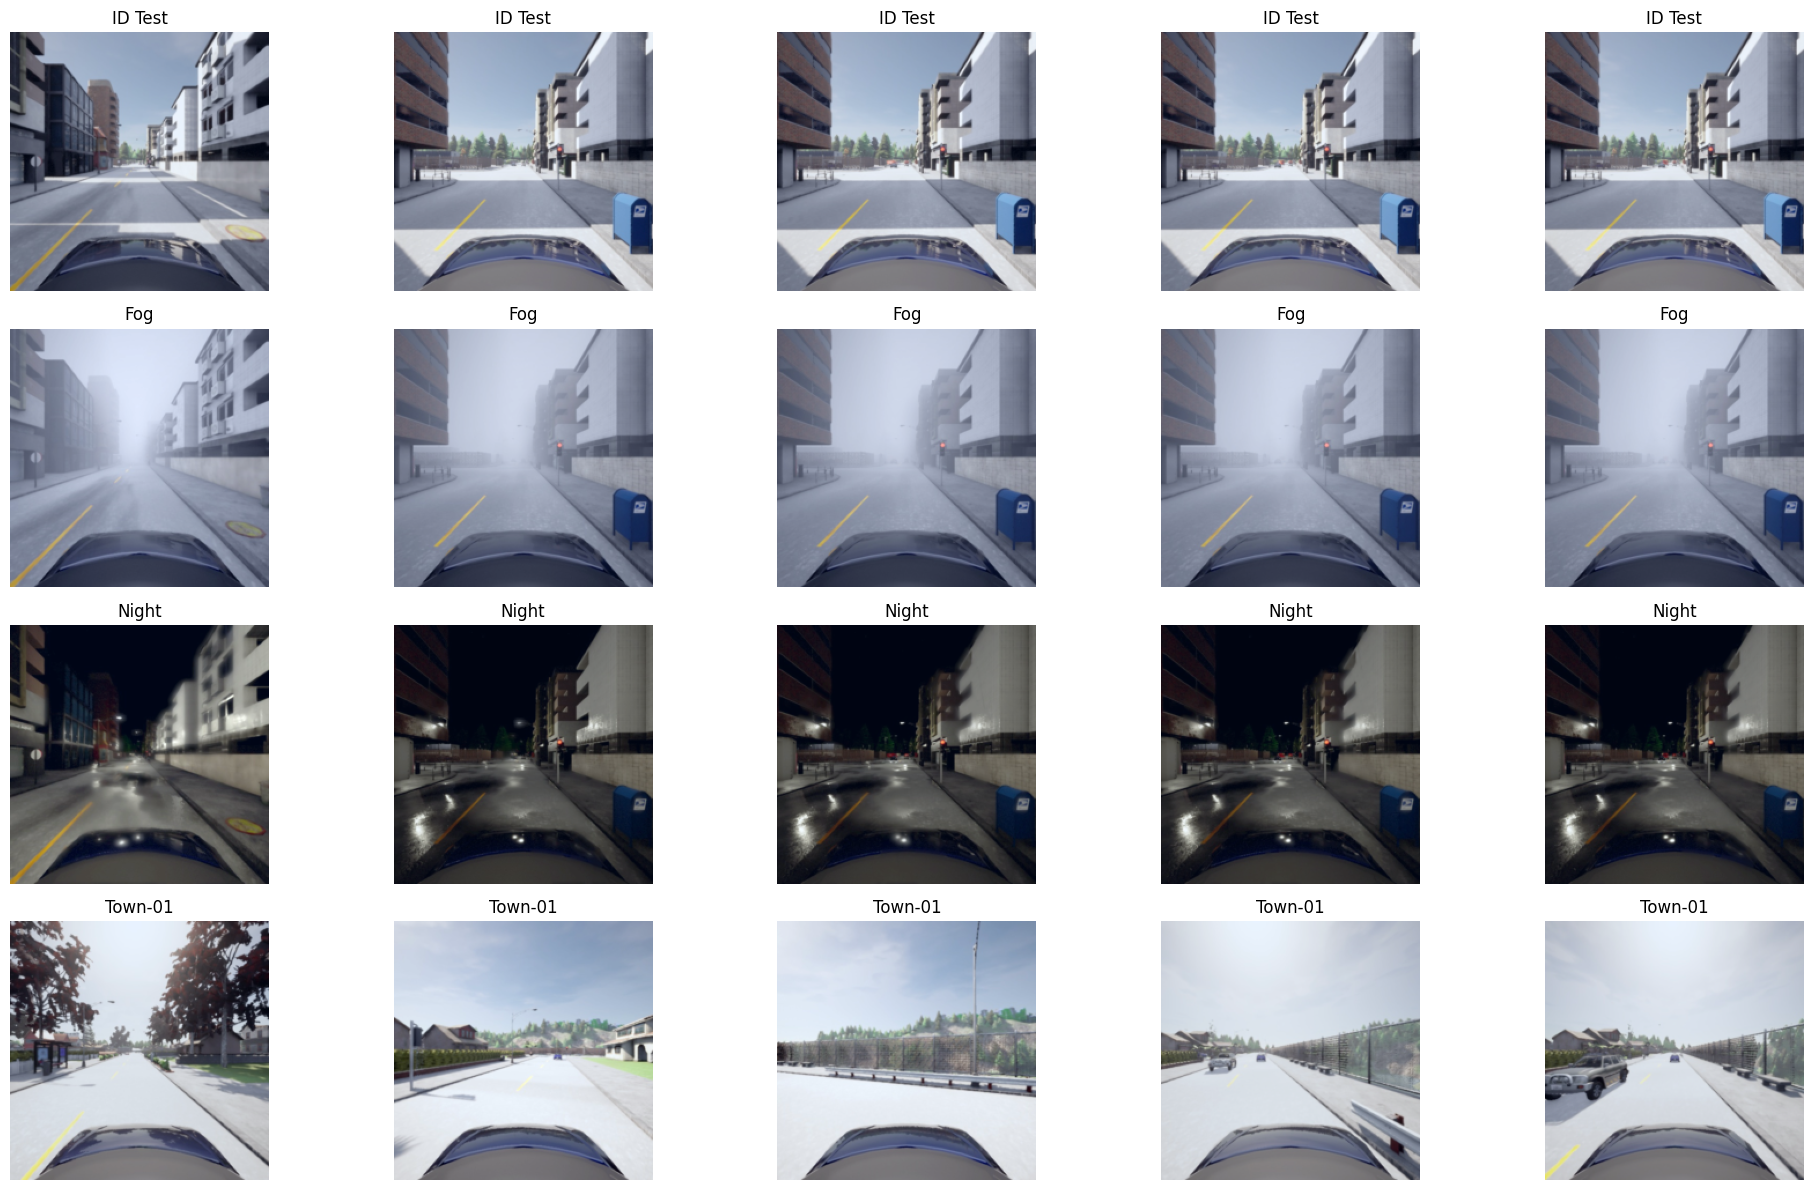

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,12))

# -----------------------
# In-Distribution Images
# -----------------------
for i in range(5):
    img, _ = vehicle_test_dataset[i]
    img = img.permute(1,2,0).numpy()
    img = (img-img.min())/(img.max()-img.min())

    plt.subplot(4,5,i+1)
    plt.imshow(img)
    plt.title("ID Test")
    plt.axis("off")

# -----------------------
# Fog Images
# -----------------------
for i in range(5):
    img, _ = fog_dataset[i]
    img = img.permute(1,2,0).numpy()
    img = (img-img.min())/(img.max()-img.min())

    plt.subplot(4,5,5+i+1)
    plt.imshow(img)
    plt.title("Fog")
    plt.axis("off")

# -----------------------
# Night Images
# -----------------------
for i in range(5):
    img, _ = night_dataset[i]
    img = img.permute(1,2,0).numpy()
    img = (img-img.min())/(img.max()-img.min())

    plt.subplot(4,5,10+i+1)
    plt.imshow(img)
    plt.title("Night")
    plt.axis("off")

# -----------------------
# Town Images
# -----------------------
for i in range(5):
    img, _ = town_dataset[i]
    img = img.permute(1,2,0).numpy()
    img = (img-img.min())/(img.max()-img.min())

    plt.subplot(4,5,15+i+1)
    plt.imshow(img)
    plt.title("Town-01")
    plt.axis("off")

plt.tight_layout()
plt.show()

Mean Confidence


In [34]:
import torch
import numpy as np

def get_confidence(model, loader):
    model.eval()

    confidences = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            confidences.extend(probs.cpu().numpy().flatten())

    return np.mean(confidences)

id_conf = get_confidence(model, test_loader)
fog_conf = get_confidence(model, fog_loader)
night_conf = get_confidence(model, night_loader)
town_conf = get_confidence(model, town_loader)

print("Mean Confidence")
print("------------------------")
print(f"ID Test  : {id_conf:.4f}")
print(f"Fog      : {fog_conf:.4f}")
print(f"Night    : {night_conf:.4f}")
print(f"Town-01  : {town_conf:.4f}")

Mean Confidence
------------------------
ID Test  : 0.7224
Fog      : 0.2929
Night    : 0.2030
Town-01  : 0.7080


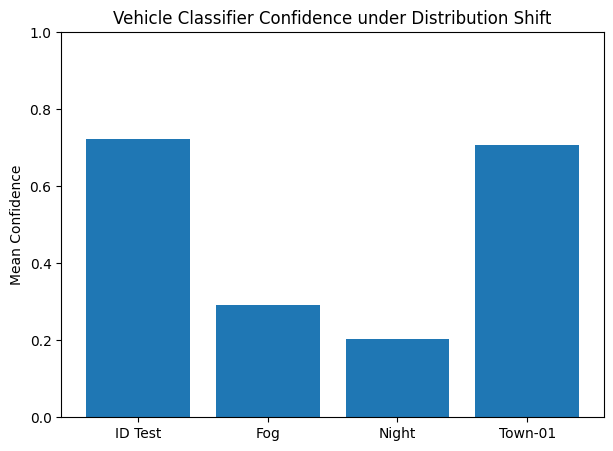

In [35]:
import matplotlib.pyplot as plt

datasets = ["ID Test", "Fog", "Night", "Town-01"]
confidences = [id_conf, fog_conf, night_conf, town_conf]

plt.figure(figsize=(7,5))
plt.bar(datasets, confidences)

plt.ylabel("Mean Confidence")
plt.title("Vehicle Classifier Confidence under Distribution Shift")
plt.ylim(0,1)

plt.show()

MSP Distribution

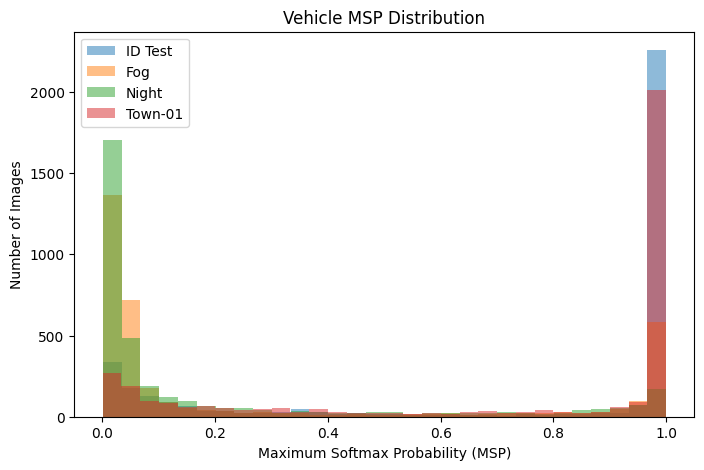

In [36]:
import numpy as np
import matplotlib.pyplot as plt

def get_msp_scores(model, loader):
    model.eval()

    scores = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            scores.extend(probs.cpu().numpy().flatten())

    return np.array(scores)

id_scores = get_msp_scores(model, test_loader)
fog_scores = get_msp_scores(model, fog_loader)
night_scores = get_msp_scores(model, night_loader)
town_scores = get_msp_scores(model, town_loader)

plt.figure(figsize=(8,5))

plt.hist(id_scores, bins=30, alpha=0.5, label="ID Test")
plt.hist(fog_scores, bins=30, alpha=0.5, label="Fog")
plt.hist(night_scores, bins=30, alpha=0.5, label="Night")
plt.hist(town_scores, bins=30, alpha=0.5, label="Town-01")

plt.xlabel("Maximum Softmax Probability (MSP)")
plt.ylabel("Number of Images")
plt.title("Vehicle MSP Distribution")
plt.legend()

plt.show()

Compute AUROC

In [37]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Combine all OOD scores
ood_scores = np.concatenate([
    fog_scores,
    night_scores,
    town_scores
])

# Labels: 0 = ID, 1 = OOD
id_labels = np.zeros(len(id_scores))
ood_labels = np.ones(len(ood_scores))

labels = np.concatenate([id_labels, ood_labels])
scores = np.concatenate([id_scores, ood_scores])

# Lower confidence = more OOD
auroc = roc_auc_score(labels, -scores)

print(f"MSP AUROC = {auroc:.4f}")

MSP AUROC = 0.7356


Feature extraction

In [38]:
from sklearn.neighbors import NearestNeighbors

# Remove final classification layer
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])
feature_extractor.to(device)
feature_extractor.eval()

def extract_features(loader):
    features = []

    with torch.no_grad():
        for images, _ in loader:

            images = images.to(device)

            feat = feature_extractor(images)
            feat = feat.view(feat.size(0), -1)

            features.append(feat.cpu().numpy())

    return np.concatenate(features, axis=0)

train_features = extract_features(train_loader)
id_features = extract_features(test_loader)
fog_features = extract_features(fog_loader)
night_features = extract_features(night_loader)
town_features = extract_features(town_loader)

print("Feature extraction complete!")

Feature extraction complete!


In [39]:
knn = NearestNeighbors(n_neighbors=5)
knn.fit(train_features)

id_knn, _ = knn.kneighbors(id_features)
fog_knn, _ = knn.kneighbors(fog_features)
night_knn, _ = knn.kneighbors(night_features)
town_knn, _ = knn.kneighbors(town_features)

id_knn = id_knn.mean(axis=1)
fog_knn = fog_knn.mean(axis=1)
night_knn = night_knn.mean(axis=1)
town_knn = town_knn.mean(axis=1)

print("k-NN detector fitted!")

k-NN detector fitted!


Plot K-NN distribution

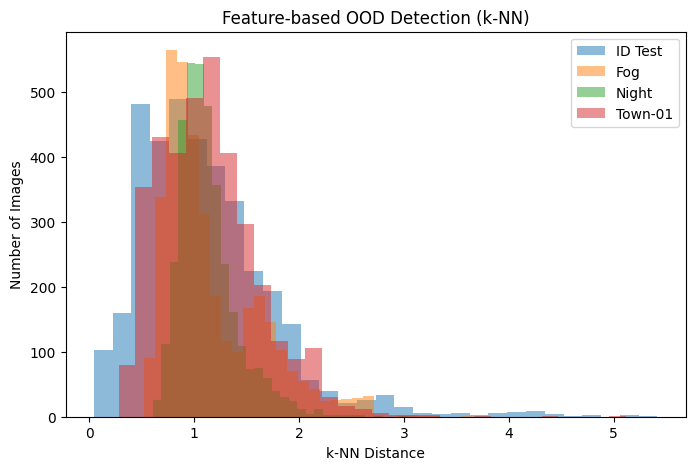

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(id_knn, bins=30, alpha=0.5, label="ID Test")
plt.hist(fog_knn, bins=30, alpha=0.5, label="Fog")
plt.hist(night_knn, bins=30, alpha=0.5, label="Night")
plt.hist(town_knn, bins=30, alpha=0.5, label="Town-01")

plt.xlabel("k-NN Distance")
plt.ylabel("Number of Images")
plt.title("Feature-based OOD Detection (k-NN)")
plt.legend()

plt.show()

Compute AUROC

In [41]:
from sklearn.metrics import roc_auc_score

ood_scores = np.concatenate([
    fog_knn,
    night_knn,
    town_knn
])

id_labels = np.zeros(len(id_knn))
ood_labels = np.ones(len(ood_scores))

labels = np.concatenate([id_labels, ood_labels])

scores = np.concatenate([
    id_knn,
    ood_scores
])

auroc_knn = roc_auc_score(labels, scores)

print(f"k-NN AUROC = {auroc_knn:.4f}")
print(f"MSP AUROC  = {auroc:.4f}")

k-NN AUROC = 0.5554
MSP AUROC  = 0.7356


Compare OOD

In [42]:
from sklearn.metrics import roc_auc_score

def compute_auroc(id_scores, ood_scores):
    labels = np.concatenate([
        np.zeros(len(id_scores)),
        np.ones(len(ood_scores))
    ])
    scores = np.concatenate([id_scores, ood_scores])
    return roc_auc_score(labels, scores)

msp_fog = compute_auroc(id_scores, fog_scores)
msp_night = compute_auroc(id_scores, night_scores)
msp_town = compute_auroc(id_scores, town_scores)

knn_fog = compute_auroc(id_knn, fog_knn)
knn_night = compute_auroc(id_knn, night_knn)
knn_town = compute_auroc(id_knn, town_knn)

print("========== AUROC Comparison ==========")
print(f"Fog     -> MSP: {msp_fog:.4f} | k-NN: {knn_fog:.4f}")
print(f"Night   -> MSP: {msp_night:.4f} | k-NN: {knn_night:.4f}")
print(f"Town-01 -> MSP: {msp_town:.4f} | k-NN: {knn_town:.4f}")

print("\nDifference (k-NN - MSP):")
print(f"Fog     : {knn_fog - msp_fog:.4f}")
print(f"Night   : {knn_night - msp_night:.4f}")
print(f"Town-01 : {knn_town - msp_town:.4f}")

========== AUROC Comparison ==========
Fog     -> MSP: 0.1933 | k-NN: 0.5548
Night   -> MSP: 0.1524 | k-NN: 0.5665
Town-01 -> MSP: 0.4476 | k-NN: 0.5450

Difference (k-NN - MSP):
Fog     : 0.3615
Night   : 0.4141
Town-01 : 0.0974
